run in alphagenome environment

## imports and setup dna model

In [1]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
import os


/Users/coraalbers/anaconda3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# indiv variant

## create dna model

In [2]:
load_dotenv()
api_key = os.getenv("AG_API_KEY")

dna_model = dna_client.create(api_key)

## load gtf formatted gene annos and MANE select transcripts
MANE Select (Matched Annotation from NCBI and EMBL-EBI) is a single, representative transcript for every human gene

In [4]:
# load gene annos from GENCODE
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Define an extractor that fetches only MANE_select transcripts per gene.
# Mane select transcripts consists of of one curated transcript per locus.
gtf_transcript = gene_annotation.filter_protein_coding(gtf)
gtf_transcript = gene_annotation.filter_to_mane_select_transcript(
    gtf_transcript
    )
transcript_extractor = transcript_utils.TranscriptExtractor(
    gtf_transcript
    )


## utility fxs

In [5]:
# @title Utilities
def generate_background_variants(
    variant: genome.Variant, max_number: int = 100
) -> pd.DataFrame:
  """Generates a dataframe of background variants for a given variant.

  This is done by creating new sequences of the same length as the alternate
  allele.

  This allows us to test if the specific sequence of the oncogenic variant has a
  greater effect than a random sequence of the same length at the same location.

  Args:
    variant: The variant to generate ism variants for.
    max_number: The maximum number of ism variants to generate.

  Returns:
    A dataframe of variants.
  """
  nucleotides = np.array(list('ACGT'), dtype='<U1')

  def generate_unique_strings(n, max_number, random_seed=42):
    """Generates unique random strings of length n."""
    rng = np.random.default_rng(random_seed)

    if 4**n < max_number:
      raise ValueError(
          'Cannot generate that many unique strings for the given length.'
      )

    generated_strings = set()
    while len(generated_strings) < max_number:
      indices = rng.integers(0, 4, size=n)
      new_string = ''.join(nucleotides[indices])
      if new_string != variant.alternate_bases:
        generated_strings.add(new_string)
    return list(generated_strings)

  permutations = []
  if 4 ** len(variant.alternate_bases) < max_number:
    # Get all
    for p in itertools.product(
        nucleotides, repeat=len(variant.alternate_bases)
    ):
      permutations.append(''.join(p))
  else:
    # Sample some
    permutations = generate_unique_strings(
        len(variant.alternate_bases), max_number
    )
  ism_candidates = pd.DataFrame({
      'ID': ['mut_' + str(variant.position) + '_' + x for x in permutations],
      'CHROM': variant.chromosome,
      'POS': variant.position,
      'REF': variant.reference_bases,
      'ALT': permutations,
      'output': 0.0,
      'original_variant': variant.name,
  })

  # Filter out REF=ALT alleles.
  ism_candidates = ism_candidates[
      ism_candidates['REF'] != ism_candidates['ALT']
  ]
  return ism_candidates


def oncogenic_and_background_variants(
    input_sequence_length: int, number_of_background_variants: int = 20
) -> pd.DataFrame:
  """Generates a dataframe of all variants for this evaluation."""
  oncogenic_variants = oncogenic_tal1_variants()

  variants = []
  for vcf_row in oncogenic_variants.itertuples():
    variants.append(
        genome.Variant(
            chromosome=str(vcf_row.CHROM),
            position=int(vcf_row.POS),
            reference_bases=vcf_row.REF,
            alternate_bases=vcf_row.ALT,
            name=vcf_row.ID,
        )
    )

  background_variants = pd.concat([
      generate_background_variants(variant, number_of_background_variants)
      for variant in variants
  ])
  all_variants = pd.concat([oncogenic_variants, background_variants])
  return inference_df(all_variants, input_sequence_length=input_sequence_length)


def vcf_row_to_variant(vcf_row: pd.Series) -> genome.Variant:
  """Parse a row of a vcf df into a genome.Variant."""
  variant = genome.Variant(
      chromosome=str(vcf_row.CHROM),
      position=int(vcf_row.POS),
      reference_bases=vcf_row.REF,
      alternate_bases=vcf_row.ALT,
      name=vcf_row.ID,
  )
  return variant


def inference_df(
    qtl_df: pd.DataFrame,
    input_sequence_length: int,
) -> pd.DataFrame:
  """Returns a pd.DataFrame with variants and intervals ready for inference."""
  df = []
  for _, row in qtl_df.iterrows():
    variant = vcf_row_to_variant(row)

    interval = genome.Interval(
        chromosome=row['CHROM'], start=row['POS'], end=row['POS']
    ).resize(input_sequence_length)

    df.append({
        'interval': interval,
        'variant': variant,
        'output': row['output'],
        'variant_id': row['ID'],
        'POS': row['POS'],
        'REF': row['REF'],
        'ALT': row['ALT'],
        'CHROM': row['CHROM'],
    })
  return pd.DataFrame(df)


def coarse_grained_mute_groups(eval_df):
  grp = []
  for row in eval_df.itertuples():
    if row.POS >= 47239290:  # MUTE site.
      if row.ALT_len > 4:
        grp.append('MUTE' + '_other')
      else:
        grp.append('MUTE' + '_' + str(row.ALT_len))
    else:
      grp.append(str(row.POS) + '_' + str(row.ALT_len))

  grp = pd.Series(grp)
  return pd.Categorical(grp, categories=sorted(grp.unique()), ordered=True)

# define variants

In [7]:
# @title Define variants of interest


lmna_variants = pd.read_csv("lmna_gnomAD_variants.csv")
  

lmna_variants.head()

,ID,CHROM,POS,REF,ALT
0,1-156114846-C-T,chr1,156114846,C,T
1,1-156114847-T-C,chr1,156114847,T,C
2,1-156114847-T-G,chr1,156114847,T,G
3,1-156114851-C-T,chr1,156114851,C,T
4,1-156114854-C-G,chr1,156114854,C,G


## visualise variant positions

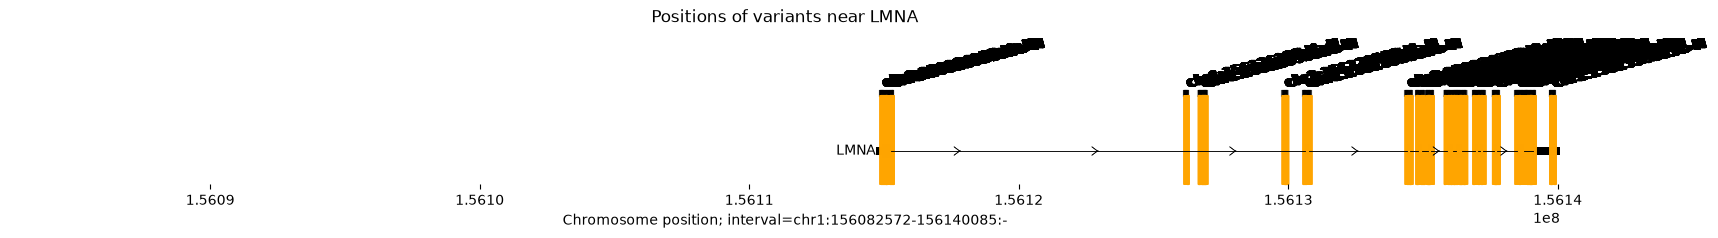

In [9]:


# Define gene interval.
lmna_interval = genome.Interval(
    chromosome='chr1', start=156082572, end=156140085, strand='-'
)

# Gather unique variant positions and plot labels.
unique_positions = lmna_variants['POS'].unique()
unique_positions.sort()

# Manually define labels to avoid overplotting.
# labels = [
#     '47212072, 47212074',
#     '',
#     '47230639',
#     '47239291 - 47239296',
#     '',
#     '',
#     '',
# ]

# Build plot.
_ = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(
            transcript_extractor.extract(lmna_interval)
        ),
    ],
    annotations=[
        plot_components.VariantAnnotation(
            [
                genome.Variant(
                    chromosome='chr1',
                    position=x,
                    reference_bases='N',
                    alternate_bases='N',
                )
                for x in unique_positions
            ],
            # labels=labels,
            use_default_labels=True,
        )
    ],
    interval=lmna_interval,
    title='Positions of variants near LMNA',
)

In [6]:
# variant info 
variant_to_test = "chr1:156105813:A>G" 
variant_string = variant_to_test
variant = genome.Variant.from_str(variant_string)
variant_interval = gene_annotation.get_gene_interval(gtf, gene_symbol='LMNA') 
variant_interval = variant_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

In [7]:
tissues = [ 
           'UBERON:0001134' # This is the Uberon Ontology ID for Skeletal muscle. 
           #Can also do more than one tissue at once 
]

In [8]:
output = model.predict_variant(
    interval = variant_interval,
    variant = variant,
    requested_outputs = [dna_client.OutputType.RNA_SEQ],
    ontology_terms = tissues
)

NameError: name 'model' is not defined

# example analysis
https://www.alphagenomedocs.com/colabs/example_analysis_workflow.html